Reading data and basic exploration

In [3]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import squarify 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
# reading data and explortaion 
data = pd.read_csv('DatasetAfricaMalaria.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594 entries, 0 to 593
Data columns (total 27 columns):
 #   Column                                                                                   Non-Null Count  Dtype  
---  ------                                                                                   --------------  -----  
 0   Country Name                                                                             594 non-null    object 
 1   Year                                                                                     594 non-null    int64  
 2   Country Code                                                                             594 non-null    object 
 3   Incidence of malaria (per 1,000 population at risk)                                      550 non-null    float64
 4   Malaria cases reported                                                                   550 non-null    float64
 5   Use of insecticide-treated bed nets (% of under-5 population)   

In [3]:
(data.isnull().sum()/len(data))*100 

Country Name                                                                                0.000000
Year                                                                                        0.000000
Country Code                                                                                0.000000
Incidence of malaria (per 1,000 population at risk)                                         7.407407
Malaria cases reported                                                                      7.407407
Use of insecticide-treated bed nets (% of under-5 population)                              77.777778
Children with fever receiving antimalarial drugs (% of children under age 5 with fever)    79.461279
Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women)      82.154882
People using safely managed drinking water services (% of population)                      83.333333
People using safely managed drinking water services, rural (% of rural population)         

In [4]:
data.describe()

,Year,"Incidence of malaria (per 1,000 population at risk)",Malaria cases reported,Use of insecticide-treated bed nets (% of under-5 population),Children with fever receiving antimalarial drugs (% of children under age 5 with fever),Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women),People using safely managed drinking water services (% of population),"People using safely managed drinking water services, rural (% of rural population)","People using safely managed drinking water services, urban (% of urban population)",People using safely managed sanitation services (% of population),...,Urban population (% of total population),Urban population growth (annual %),People using at least basic drinking water services (% of population),"People using at least basic drinking water services, rural (% of rural population)","People using at least basic drinking water services, urban (% of urban population)",People using at least basic sanitation services (% of population),"People using at least basic sanitation services, rural (% of rural population)","People using at least basic sanitation services, urban (% of urban population)",latitude,longitude
count,594.000000,550.000000,5.500000e+02,132.000000,122.000000,106.000000,99.000000,88.000000,176.000000,132.000000,...,588.000000,588.000000,588.000000,566.000000,566.000000,588.000000,566.000000,566.000000,594.000000,594.000000
mean,2012.000000,190.087491,1.068330e+06,42.530303,30.201639,15.013958,33.478990,12.470568,51.549545,28.768939,...,43.164116,3.523061,65.994915,51.449576,84.268498,39.469796,28.077208,48.088375,2.828796,17.342546
std,3.164943,163.054527,2.192802e+06,20.157059,18.903198,12.389166,26.678321,10.078371,24.157416,18.631510,...,18.086118,1.456244,17.283361,18.927868,9.307285,26.304934,24.046725,21.802128,15.678226,20.041257
min,2007.000000,0.000000,0.000000e+00,1.000000,0.500000,0.000000,5.770000,0.930000,11.200000,6.370000,...,9.860000,-4.650000,28.960000,17.050000,52.010000,4.990000,1.890000,12.580000,-30.559482,-24.013197
25%,2009.000000,30.857500,2.211750e+03,26.675000,17.275000,5.763285,8.975000,4.185000,34.125000,16.532500,...,28.795000,2.512500,52.375000,37.075000,78.080000,18.197500,8.842500,30.775000,-6.369028,0.824782
50%,2012.000000,174.775000,1.130260e+05,42.900000,29.300000,11.500000,28.390000,10.675000,51.365000,25.410000,...,41.560000,3.730000,64.470000,50.435000,85.420000,32.555000,18.815000,44.695000,6.744051,18.611308
75%,2015.000000,347.637500,1.154808e+06,56.325000,42.625000,21.850000,43.890000,16.887500,70.747500,35.725000,...,56.945000,4.450000,79.165000,62.245000,90.082500,54.810000,38.082500,58.845000,12.862807,31.465866
max,2017.000000,585.540000,1.682113e+07,95.500000,76.900000,59.600000,92.660000,39.930000,89.540000,78.120000,...,88.980000,7.400000,99.870000,99.830000,99.920000,100.000000,95.180000,98.300000,33.886917,57.552152


<AxesSubplot:>

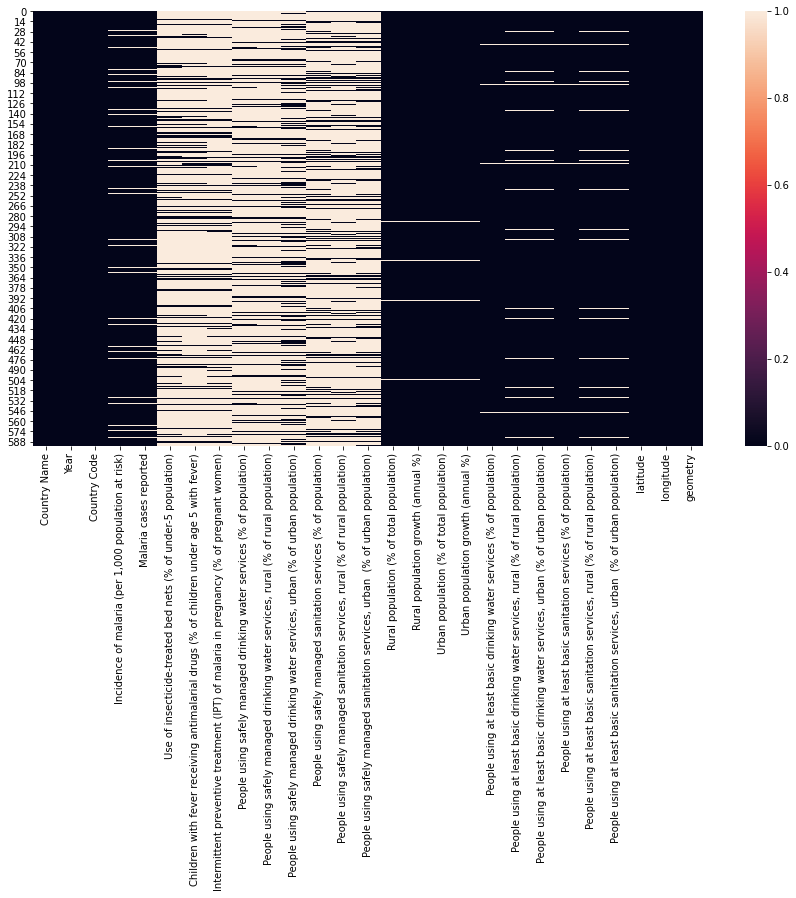

In [ ]:
plt.figure(figsize=(15,8))
sns.heatmap(data.isnull())

Data cleaning

In [6]:
columns_to_clean = [col for col in  data.columns if data[col].isnull().sum()>60]
columns_to_clean

['Use of insecticide-treated bed nets (% of under-5 population)',
 'Children with fever receiving antimalarial drugs (% of children under age 5 with fever)',
 'Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women)',
 'People using safely managed drinking water services (% of population)',
 'People using safely managed drinking water services, rural (% of rural population)',
 'People using safely managed drinking water services, urban (% of urban population)',
 'People using safely managed sanitation services (% of population)',
 'People using safely managed sanitation services, rural (% of rural population)',
 'People using safely managed sanitation services, urban  (% of urban population)']

In [7]:
data = data.drop(columns = columns_to_clean )

In [8]:
data.head()

,Country Name,Year,Country Code,"Incidence of malaria (per 1,000 population at risk)",Malaria cases reported,Rural population (% of total population),Rural population growth (annual %),Urban population (% of total population),Urban population growth (annual %),People using at least basic drinking water services (% of population),"People using at least basic drinking water services, rural (% of rural population)","People using at least basic drinking water services, urban (% of urban population)",People using at least basic sanitation services (% of population),"People using at least basic sanitation services, rural (% of rural population)","People using at least basic sanitation services, urban (% of urban population)",latitude,longitude,geometry
0,Algeria,2007,DZA,0.01,26.0,34.65,-0.60,65.35,2.71,91.68,85.83,94.78,85.85,76.94,90.57,28.033886,1.659626,POINT (28.033886 1.659626)
1,Angola,2007,AGO,286.72,1533485.0,42.48,1.91,57.52,5.01,47.96,23.77,65.83,37.26,14.00,54.44,-11.202692,17.873887,POINT (-11.202692 17.873887)
2,Benin,2007,BEN,480.24,0.0,58.44,1.99,41.56,4.09,63.78,54.92,76.24,11.80,4.29,22.36,9.307690,2.315834,POINT (9.307689999999999 2.315834)
3,Botswana,2007,BWA,1.03,390.0,42.07,-1.44,57.93,4.80,78.89,57.60,94.35,61.60,39.99,77.30,-22.328474,24.684866,POINT (-22.328474 24.684866)
4,Burkina Faso,2007,BFA,503.80,44246.0,77.00,2.16,23.00,5.91,52.27,45.13,76.15,15.60,6.38,46.49,12.238333,-1.561593,POINT (12.238333 -1.561593)


<AxesSubplot:>

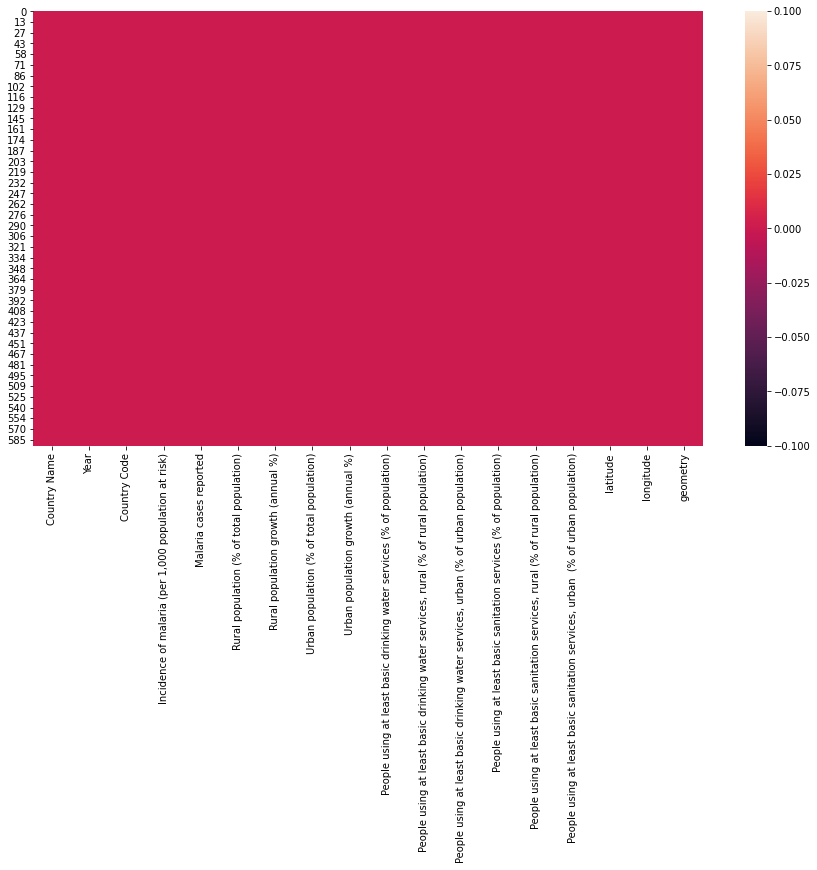

In [9]:
data = data.dropna(axis=0)
plt.figure(figsize=(15,8))
sns.heatmap(data.isnull())

In [10]:
data.columns

Index(['Country Name', 'Year', 'Country Code',
       'Incidence of malaria (per 1,000 population at risk)',
       'Malaria cases reported', 'Rural population (% of total population)',
       'Rural population growth (annual %)',
       'Urban population (% of total population)',
       'Urban population growth (annual %)',
       'People using at least basic drinking water services (% of population)',
       'People using at least basic drinking water services, rural (% of rural population)',
       'People using at least basic drinking water services, urban (% of urban population)',
       'People using at least basic sanitation services (% of population)',
       'People using at least basic sanitation services, rural (% of rural population)',
       'People using at least basic sanitation services, urban  (% of urban population)',
       'latitude', 'longitude', 'geometry'],
      dtype='object')

**the data is completely  cleaned**

## Number of cases in the countries where they have the most rate of cases

In [11]:
malarias_cas_percountry  =  data[['Country Name','Malaria cases reported']].groupby('Country Name').sum().sort_values(by='Malaria cases reported')
malarias_cas_percountry = malarias_cas_percountry.tail(7)
malarias_cas_percountry

,Malaria cases reported
Country Name,
Ghana,28008309.0
Nigeria,40066570.0
Burundi,40249714.0
Uganda,41126230.0
Burkina Faso,41601963.0
Mozambique,43984158.0
"Congo, Dem. Rep.",77555524.0


In [12]:
e= malarias_cas_percountry.tail(7)
e["Country Name"] = ['Ghana','Nigeria','Burundi','Uganda','Burkina Faso','Mozambique','Congo, Dem. Rep']
e

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


,Malaria cases reported,Country Name
Country Name,,
Ghana,28008309.0,Ghana
Nigeria,40066570.0,Nigeria
Burundi,40249714.0,Burundi
Uganda,41126230.0,Uganda
Burkina Faso,41601963.0,Burkina Faso
Mozambique,43984158.0,Mozambique
"Congo, Dem. Rep.",77555524.0,"Congo, Dem. Rep"


<AxesSubplot:xlabel='Malaria cases reported', ylabel='Country Name'>

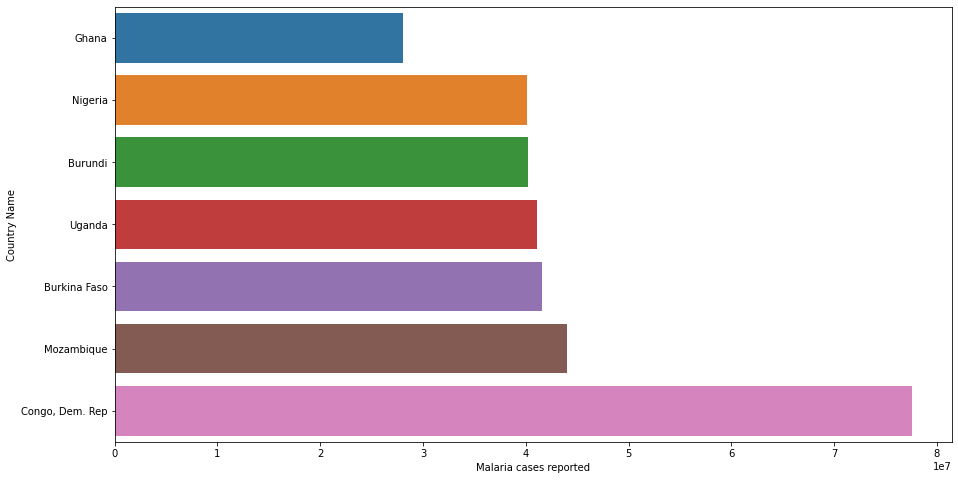

In [13]:
#from 2007 to 2017
plt.figure(figsize=(15,8))
sns.barplot(x="Malaria cases reported", y="Country Name", data=e)

<AxesSubplot:xlabel='Year', ylabel='Malaria cases reported'>

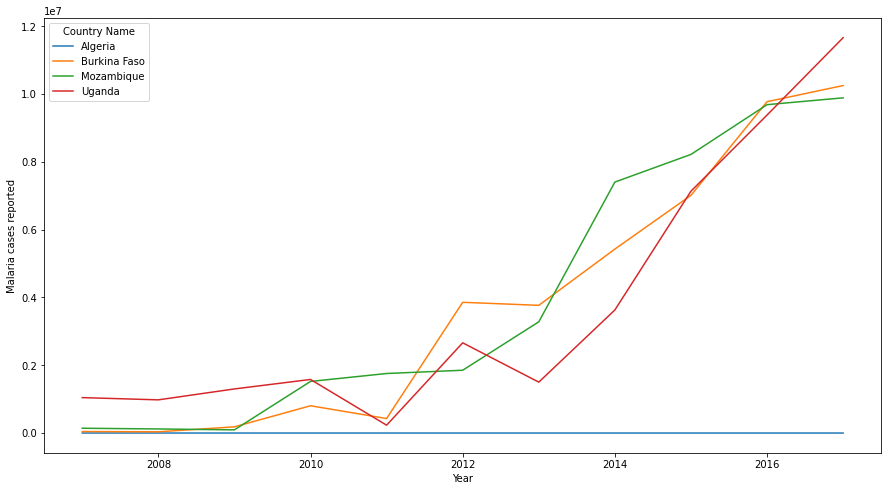

In [14]:
#### 
plt.figure(figsize=(15,8))
data_1 = data[data['Country Name'].isin( ['Uganda','Burkina Faso','Mozambique','Congo, Dem. Rep','Algeria'])]
sns.lineplot(data=data_1, x="Year", y='Malaria cases reported', hue='Country Name')

In [15]:
data[['Country Name','Malaria cases reported']].groupby('Country Name').sum().sort_values(by='Malaria cases reported')['Malaria cases reported']

Country Name
Morocco                            0.0
Egypt, Arab Rep.                   0.0
Algeria                           94.0
Cabo Verde                       699.0
Eswatini                        4531.0
Botswana                        8756.0
Sao Tome and Principe          54276.0
Djibouti                       61718.0
South Africa                   93089.0
Eritrea                       106918.0
Mauritania                    117335.0
Namibia                       120908.0
Somalia                       254342.0
Gabon                         264144.0
Comoros                       289016.0
Equatorial Guinea             336825.0
Guinea-Bissau                 749386.0
Congo, Rep.                   932292.0
Gambia, The                  1675997.0
Central African Republic     2177952.0
South Sudan                  2191287.0
Senegal                      3283980.0
Zimbabwe                     3344410.0
Cameroon                     4373628.0
Guinea                       4580444.0
Madagascar  

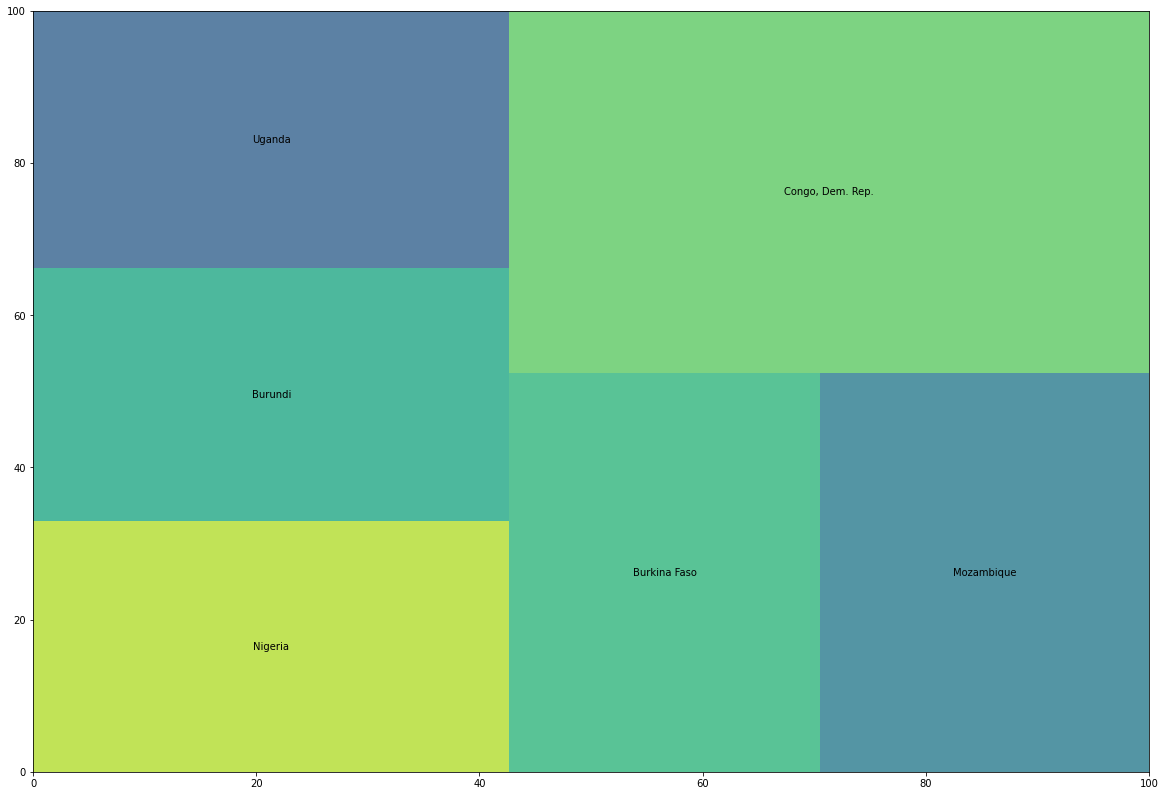

In [16]:
crb = data[['Country Name','Malaria cases reported']].groupby('Country Name').sum().sort_values(by='Malaria cases reported')
label =data[['Country Name','Malaria cases reported']].groupby('Country Name').sum().sort_values(by='Malaria cases reported').index.get_level_values(0).tolist()
sizes = [crb['Malaria cases reported'][i]  for i in range(len(crb)) ]
sizes=sizes[1:]
label = label[1:]
plt.figure(figsize=(20,14))
squarify.plot(sizes= sizes[len(sizes)-6:]  ,label = label[len(sizes)-6:] ,alpha=0.8 )
plt.show()

In [17]:
data.columns

Index(['Country Name', 'Year', 'Country Code',
       'Incidence of malaria (per 1,000 population at risk)',
       'Malaria cases reported', 'Rural population (% of total population)',
       'Rural population growth (annual %)',
       'Urban population (% of total population)',
       'Urban population growth (annual %)',
       'People using at least basic drinking water services (% of population)',
       'People using at least basic drinking water services, rural (% of rural population)',
       'People using at least basic drinking water services, urban (% of urban population)',
       'People using at least basic sanitation services (% of population)',
       'People using at least basic sanitation services, rural (% of rural population)',
       'People using at least basic sanitation services, urban  (% of urban population)',
       'latitude', 'longitude', 'geometry'],
      dtype='object')

**representation geographic**

In [18]:
import folium
from folium import Choropleth, Circle, Marker
from folium.plugins import HeatMap, MarkerCluster

# Create a map
m_2 = folium.Map(location=[9.000,18.000], tiles='cartodbpositron', zoom_start=3)

# Add points to the map
for idx, row in data.iterrows():
    Marker([row['latitude'], row['longitude']]).add_to(m_2)

# Display the map
m_2

In [19]:
data.columns

Index(['Country Name', 'Year', 'Country Code',
       'Incidence of malaria (per 1,000 population at risk)',
       'Malaria cases reported', 'Rural population (% of total population)',
       'Rural population growth (annual %)',
       'Urban population (% of total population)',
       'Urban population growth (annual %)',
       'People using at least basic drinking water services (% of population)',
       'People using at least basic drinking water services, rural (% of rural population)',
       'People using at least basic drinking water services, urban (% of urban population)',
       'People using at least basic sanitation services (% of population)',
       'People using at least basic sanitation services, rural (% of rural population)',
       'People using at least basic sanitation services, urban  (% of urban population)',
       'latitude', 'longitude', 'geometry'],
      dtype='object')

## Number of cases in the countries where they have the most rate of cases

In [20]:
import plotly.express as px
df = data
fig = px.scatter_geo(df, locations="Country Code", color="Country Name",
                     hover_name="Country Name", size='Malaria cases reported',
                     animation_frame="Year",
                     projection="natural earth")
fig.show()

In [21]:
data.columns

Index(['Country Name', 'Year', 'Country Code',
       'Incidence of malaria (per 1,000 population at risk)',
       'Malaria cases reported', 'Rural population (% of total population)',
       'Rural population growth (annual %)',
       'Urban population (% of total population)',
       'Urban population growth (annual %)',
       'People using at least basic drinking water services (% of population)',
       'People using at least basic drinking water services, rural (% of rural population)',
       'People using at least basic drinking water services, urban (% of urban population)',
       'People using at least basic sanitation services (% of population)',
       'People using at least basic sanitation services, rural (% of rural population)',
       'People using at least basic sanitation services, urban  (% of urban population)',
       'latitude', 'longitude', 'geometry'],
      dtype='object')

<AxesSubplot:>

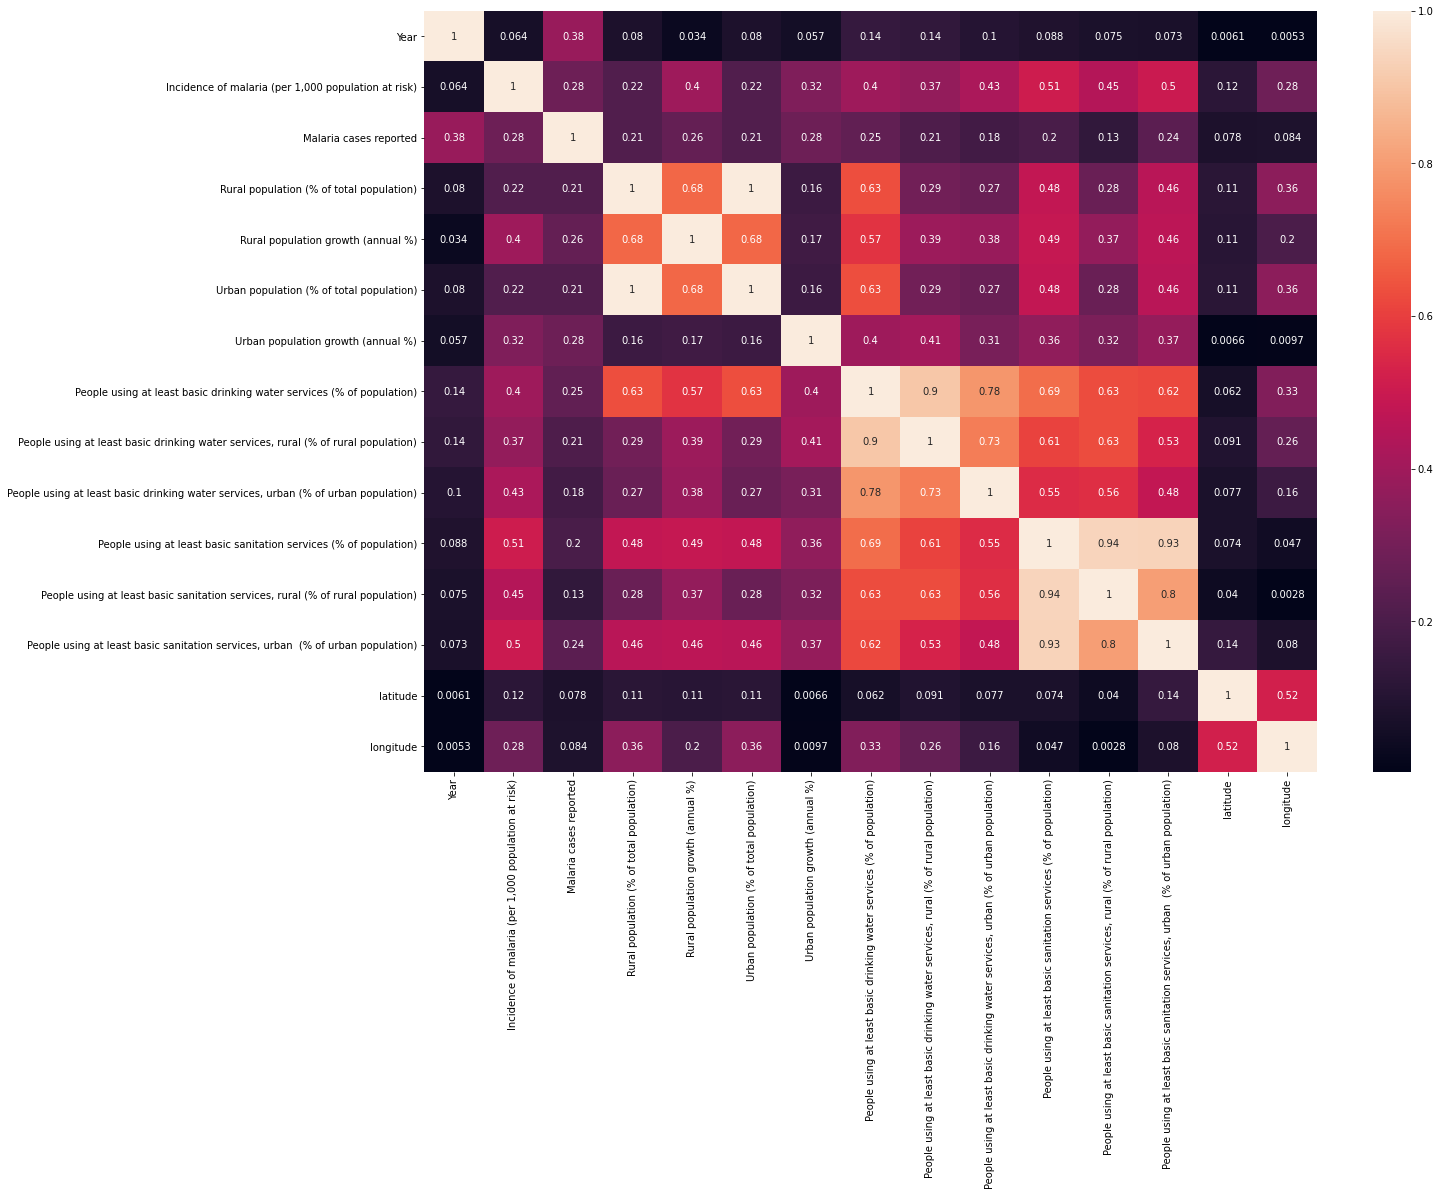

In [22]:
plt.figure(figsize=(20,14))
sns.heatmap(data.corr().abs(),annot=True)

<AxesSubplot:>

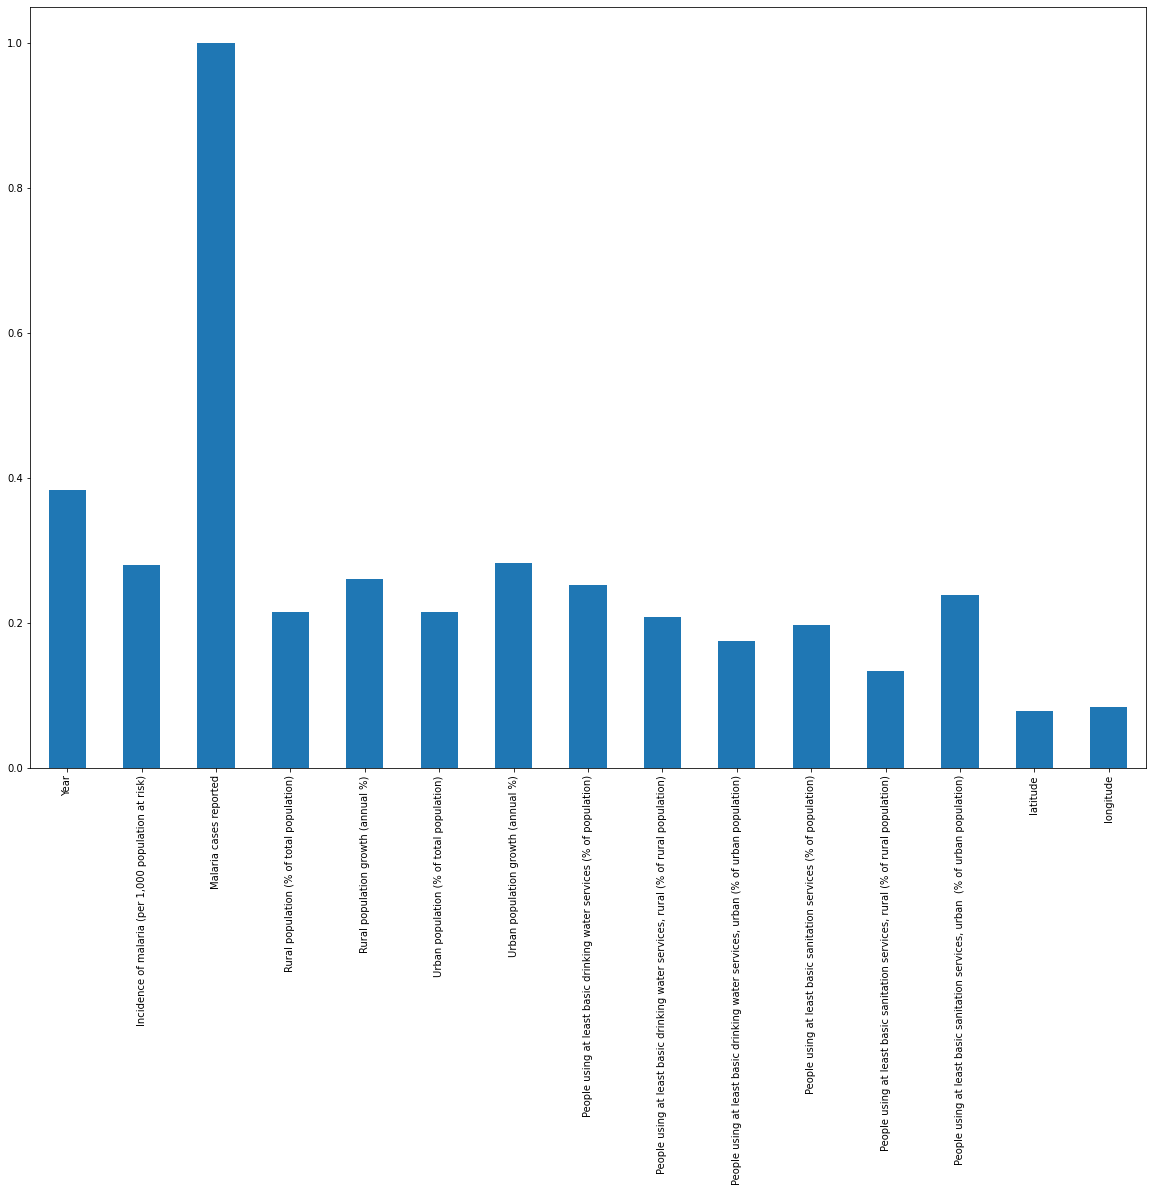

In [23]:
plt.figure(figsize=(20,14))
data.corr().abs()['Malaria cases reported'].plot(kind='bar')

In [24]:
data.columns

Index(['Country Name', 'Year', 'Country Code',
       'Incidence of malaria (per 1,000 population at risk)',
       'Malaria cases reported', 'Rural population (% of total population)',
       'Rural population growth (annual %)',
       'Urban population (% of total population)',
       'Urban population growth (annual %)',
       'People using at least basic drinking water services (% of population)',
       'People using at least basic drinking water services, rural (% of rural population)',
       'People using at least basic drinking water services, urban (% of urban population)',
       'People using at least basic sanitation services (% of population)',
       'People using at least basic sanitation services, rural (% of rural population)',
       'People using at least basic sanitation services, urban  (% of urban population)',
       'latitude', 'longitude', 'geometry'],
      dtype='object')

In [25]:
import plotly.express as px
df = data
px.scatter(df, x="Year", y='Malaria cases reported', animation_frame="Year", animation_group='Country Name',
           size='Incidence of malaria (per 1,000 population at risk)', color='Country Name', hover_name='Country Name',
           log_x = False, size_max=55, range_x=[2006,2019])

<a id="3"></a> <br>
# 7. conclusion

as we can see in previous results ,the correlation between the malaria cases and the other features is so low ~~ 0.2 
so we can't assosiated the malaria disease to a spesific causes as the water distrubution services or the rural population
but in fact this disease related  to many other feature like polution and  use of shared needles or syringes